# Туторіал: статистичний аналіз даних у Python для OSINT

**Заняття №17 — Статистика в OSINT**

Цей туторіал навчить вас **інструментів**, потрібних для виконання домашнього завдання: огляд даних, описова статистика, візуалізація розподілів, кореляційний аналіз, логістична регресія та кластеризація.

> ⚠️ **Важливо.** Тут ми працюємо з **іншим набором даних** — статтями новин (розпізнавання «клікбейту»), а **не** з акаунтами соцмереж із домашнього завдання. Ваше завдання — зрозуміти, *як працює кожен метод*, а потім **самостійно** застосувати ці самі кроки до свого файлу `accounts.csv`. Готових відповідей на ДЗ тут немає.

**Що знадобиться:** `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `scipy`. У Google Colab вони вже встановлені; локально — `pip install pandas numpy matplotlib scikit-learn scipy`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Налаштування для охайних графіків
plt.rcParams['figure.figsize'] = (7, 4)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

## 0. Навчальний набір даних

Щоб не шукати зовнішній датасет, згенеруємо синтетичну вибірку **новинних статей**. Частина з них — звичайні статті, частина — «клікбейт» (короткі, з багатьма знаками оклику, але активно поширювані).

Зверніть увагу на колонки — вони *відрізняються* від тих, що у вашому ДЗ. Це навмисно.

In [2]:
rng = np.random.default_rng(7)

# Звичайні статті
n_normal = 300
normal = pd.DataFrame({
    'word_count':  rng.integers(300, 1500, n_normal),   # довжина тексту
    'num_links':   rng.integers(1, 15, n_normal),        # кількість посилань
    'num_exclam':  rng.poisson(1.2, n_normal),           # знаки оклику
    'share_count': rng.gamma(2, 40, n_normal).round(0),  # поширення
    'is_clickbait': 0})

# Клікбейт
n_click = 120
click = pd.DataFrame({
    'word_count':  rng.integers(80, 500, n_click),
    'num_links':   rng.integers(0, 4, n_click),
    'num_exclam':  rng.poisson(6, n_click),
    'share_count': rng.gamma(5, 120, n_click).round(0),
    'is_clickbait': 1})

articles = (pd.concat([normal, click], ignore_index=True)
              .sample(frac=1, random_state=7).reset_index(drop=True))
articles.to_csv('articles.csv', index=False)
print('Розмір:', articles.shape)
articles.head()

Розмір: (420, 5)


,word_count,num_links,num_exclam,share_count,is_clickbait
0,833,3,2,71.00,0
1,362,10,5,32.00,0
2,452,3,5,420.00,1
3,999,13,2,88.00,0
4,122,1,7,769.00,1


## 1. Первинний огляд даних (pandas)

Перш ніж рахувати статистику, треба «познайомитися» з даними. Основні методи `pandas`:

- `pd.read_csv(...)` — завантажити CSV у таблицю (`DataFrame`).
- `.head()` — перші рядки.
- `.shape` — (кількість рядків, кількість стовпців).
- `.info()` — типи даних і пропуски.
- `.describe()` — швидке статистичне зведення по числових стовпцях.
- `.value_counts()` — частоти значень категоріальної ознаки.

In [3]:
df = pd.read_csv('articles.csv')   # так само ви завантажите accounts.csv

print('Форма таблиці:', df.shape)
df.info()

Форма таблиці: (420, 5)
<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   word_count    420 non-null    int64  
 1   num_links     420 non-null    int64  
 2   num_exclam    420 non-null    int64  
 3   share_count   420 non-null    float64
 4   is_clickbait  420 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 16.5 KB


In [4]:
# Зведена статистика по всіх числових стовпцях одразу
df.describe()

,word_count,num_links,num_exclam,share_count,is_clickbait
count,420.00,420.00,420.00,420.00,420.00
mean,745.49,5.87,2.63,227.87,0.29
std,420.87,4.39,2.88,283.31,0.45
min,81.00,0.00,0.00,2.00,0.00
25%,381.75,2.00,1.00,44.75,0.00
50%,714.00,5.00,2.00,98.50,0.00
75%,1098.50,10.00,4.00,319.00,1.00
max,1499.00,14.00,13.00,1545.00,1.00


In [5]:
# Частка класів: скільки клікбейту у вибірці?
counts = df['is_clickbait'].value_counts()
print(counts)
print('\nЧастка клікбейту: {:.1%}'.format(counts.get(1, 0) / len(df)))

is_clickbait
0    300
1    120
Name: count, dtype: int64

Частка клікбейту: 28.6%


**Як читати результат.** `describe()` показує середнє (`mean`), стандартне відхилення (`std`), мінімум/максимум і квартилі. Якщо середнє сильно більше за медіану (50%), розподіл, імовірно, має «хвіст» праворуч (викиди).

> 🔎 **Спробуйте самі (для ДЗ):** завантажте `accounts.csv`, подивіться `info()` та `describe()`, порахуйте частку ботів (`is_bot`).

## 2. Описова статистика

Чотири ключові міри центру та розкиду:

| Міра | pandas | Що показує |
|------|--------|------------|
| Середнє | `.mean()` | «центр ваги», чутливе до викидів |
| Медіана | `.median()` | середній елемент, стійка до викидів |
| Мода | `.mode()` | найчастіше значення |
| Стандартне відхилення | `.std()` | розкид навколо середнього |
| Діапазон | `.max() - .min()` | загальний розмах |

**Чому це важливо:** коли в даних є екстремальні значення (наприклад, вірусна стаття з мільйонами поширень), **середнє** «зміщується», а **медіана** краще описує типовий випадок.

In [6]:
col = 'share_count'
s = df[col]

print(f'Ознака: {col}')
print(f'  Середнє (mean):      {s.mean():.2f}')
print(f'  Медіана (median):    {s.median():.2f}')
print(f'  Мода (mode):         {s.mode().iloc[0]:.2f}')
print(f'  Станд. відх. (std):  {s.std():.2f}')
print(f'  Діапазон (range):    {s.max() - s.min():.2f}  (min={s.min()}, max={s.max()})')

Ознака: share_count
  Середнє (mean):      227.87
  Медіана (median):    98.50
  Мода (mode):         36.00
  Станд. відх. (std):  283.31
  Діапазон (range):    1543.00  (min=2.0, max=1545.0)


In [7]:
# Порівняння середнього й медіани по кількох ознаках одразу
summary = df[['word_count', 'num_exclam', 'share_count']].agg(['mean', 'median', 'std'])
summary

,word_count,num_exclam,share_count
mean,745.49,2.63,227.87
median,714.00,2.00,98.50
std,420.87,2.88,283.31


Якщо для `share_count` середнє помітно більше за медіану — це сигнал асиметрії та наявності викидів. Саме тут медіана інформативніша.

> 🔎 **Спробуйте самі (для ДЗ):** порахуйте ці ж міри для `followers` та `posts_per_day` у `accounts.csv` і поясніть, де середнє й медіана розходяться найбільше.

## 3. Візуалізація розподілів

Числа — добре, але форму даних краще *побачити*.

- **Гістограма** (`plt.hist`) — як часто трапляються різні значення.
- **Boxplot** (`plt.boxplot`) — медіана, квартилі та викиди (точки за «вусами»).

Форми розподілів: *симетричний* (дзвоноподібний), *асиметричний* (хвіст в один бік), *мультимодальний* (кілька піків).

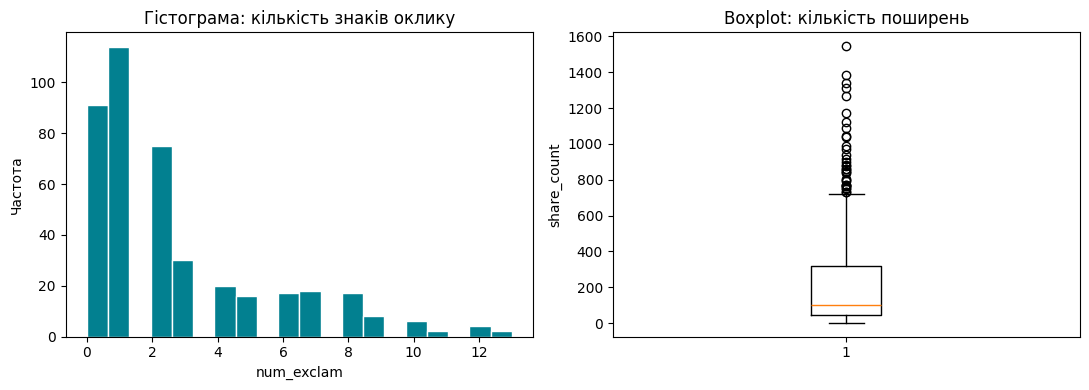

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Гістограма
axes[0].hist(df['num_exclam'], bins=20, color='#028090', edgecolor='white')
axes[0].set_title('Гістограма: кількість знаків оклику')
axes[0].set_xlabel('num_exclam'); axes[0].set_ylabel('Частота')

# Boxplot
axes[1].boxplot(df['share_count'], vert=True)
axes[1].set_title('Boxplot: кількість поширень')
axes[1].set_ylabel('share_count')

plt.tight_layout()
plt.show()

**Як читати boxplot:** лінія всередині коробки — медіана; межі коробки — 1-й і 3-й квартилі; окремі точки вгорі — викиди. Бачите багато точок зверху → розподіл має довгий правий хвіст.

> 🔎 **Спробуйте самі (для ДЗ):** побудуйте гістограму `posts_per_day` і boxplot `followers` для `accounts.csv`; опишіть форму та викиди.

## 4. Кореляційний аналіз

Кореляція показує, чи **пов'язані** дві числові змінні.

- Коефіцієнт `r` від **−1** (сильний обернений зв'язок) до **+1** (сильний прямий); `0` — зв'язку немає.
- `df.corr()` — матриця кореляцій (за замовчуванням — **Пірсона**, для лінійних зв'язків).
- Для порядкових даних або викидів краще **Спірмен**: `df.corr(method='spearman')`.

❗ **Кореляція ≠ причинність.** Навіть сильний зв'язок не доводить, що одна змінна *спричиняє* іншу.

In [9]:
# Матриця кореляцій (Пірсон)
corr = df[['word_count', 'num_links', 'num_exclam', 'share_count']].corr()
corr

,word_count,num_links,num_exclam,share_count
word_count,1.00,0.47,-0.58,-0.59
num_links,0.47,1.00,-0.55,-0.53
num_exclam,-0.58,-0.55,1.00,0.72
share_count,-0.59,-0.53,0.72,1.00


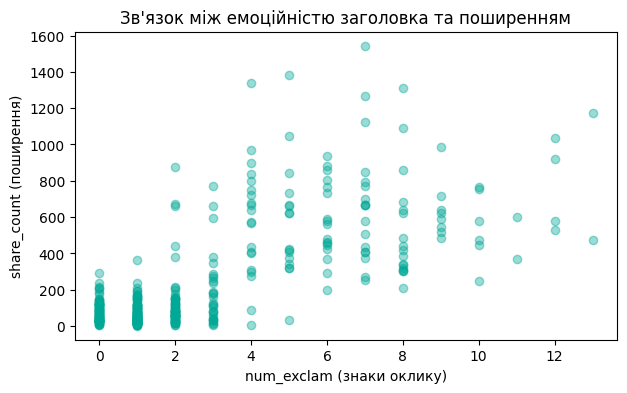

In [10]:
# Візуалізація однієї пари: діаграма розсіювання (scatter)
plt.scatter(df['num_exclam'], df['share_count'], alpha=0.4, color='#00A896')
plt.xlabel('num_exclam (знаки оклику)')
plt.ylabel('share_count (поширення)')
plt.title('Зв\'язок між емоційністю заголовка та поширенням')
plt.show()

In [11]:
# Точкове значення коефіцієнтів за scipy: Пірсон vs Спірмен
from scipy.stats import pearsonr, spearmanr

r_p, _ = pearsonr(df['num_exclam'], df['share_count'])
r_s, _ = spearmanr(df['num_exclam'], df['share_count'])
print(f'Пірсон r  = {r_p:.2f}')
print(f'Спірмен r = {r_s:.2f}')

Пірсон r  = 0.72
Спірмен r = 0.61


> 🔎 **Спробуйте самі (для ДЗ):** побудуйте `df.corr()` для числових ознак `accounts.csv`, знайдіть найсильнішу пару та поясніть, чому кореляція не означає причинність.

## 5. Класифікація: логістична регресія

Логістична регресія прогнозує **ймовірність** належності об'єкта до класу (тут — звичайна стаття `0` чи клікбейт `1`). Це базовий метод бінарної класифікації.

Кроки:
1. Розділити ознаки `X` і мітку `y`.
2. Поділити на навчальну та тестову вибірки (`train_test_split`).
3. Навчити модель (`fit`) і зробити прогноз (`predict`).
4. Оцінити якість: **accuracy** (загальна точність), **precision** (яка частка позначених клікбейтом справді клікбейт), **recall** (яку частку реального клікбейту ми спіймали).

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

features = ['word_count', 'num_links', 'num_exclam', 'share_count']
X = df[features]
y = df['is_clickbait']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print('Матриця плутанини (confusion matrix):')
print(confusion_matrix(y_test, y_pred))
print('\nЗвіт класифікації:')
print(classification_report(y_test, y_pred, digits=2))

Матриця плутанини (confusion matrix):
[[90  0]
 [ 0 36]]

Звіт класифікації:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        36

    accuracy                           1.00       126
   macro avg       1.00      1.00      1.00       126
weighted avg       1.00      1.00      1.00       126



**Чому важливий recall.** Якщо ми шукаємо шкідливі об'єкти (клікбейт, боти, фейки), пропустити їх (низький recall) часто гірше, ніж зайвий раз перевірити «чисту» статтю. Тому дивіться не лише на accuracy, а й на precision/recall разом.

> 🔎 **Спробуйте самі (для ДЗ):** навчіть `LogisticRegression` прогнозувати `is_bot` за п'ятьма ознаками `accounts.csv` і поясніть, чому recall тут критичний.

## 6. Кластеризація: K-means

Кластеризація — це **навчання без учителя**: ми групуємо схожі об'єкти, *не використовуючи* мітку. Це імітує реальну ситуацію, коли заздалегідь невідомо, хто є хто.

- Ознаки спершу **стандартизують** (`StandardScaler`), бо K-means чутливий до масштабу.
- `KMeans(n_clusters=2)` шукає 2 групи.
- Потім можна *порівняти* кластери з реальними мітками, щоб оцінити, наскільки добре групування їх вловило.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

X_scaled = StandardScaler().fit_transform(df[features])

km = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = km.fit_predict(X_scaled)

# Порівняння кластерів із реальними мітками (мітку НЕ давали алгоритму!)
compare = pd.crosstab(clusters, df['is_clickbait'],
                      rownames=['Кластер'], colnames=['Реальний клас'])
compare

Реальний клас,0,1
Кластер,,
0,299,0
1,1,120


Якщо в таблиці кожен кластер «збігається» переважно з одним класом — алгоритм добре відокремив групи лише за структурою даних.

**А якщо потрібні аномалії?** Для пошуку *поодиноких* підозрілих об'єктів і відсіювання «шуму» краще підходить **DBSCAN** (`from sklearn.cluster import DBSCAN`): він знаходить щільні скупчення й позначає рідкісні точки як шум (`-1`), тоді як K-means обов'язково розкидає всі точки по K групах.

> 🔎 **Спробуйте самі (для ДЗ):** застосуйте `KMeans(k=2)` до стандартизованих ознак `accounts.csv` (без `is_bot`) і порівняйте кластери з реальними мітками.

## 7. Трактування результатів та обмеження

Статистика дає **ймовірності, а не 100% впевненість**. Кілька правил, які варто тримати в голові (і відобразити у висновках ДЗ):

- **Кореляція ≠ причинність** — зв'язок не доводить причину.
- **Репрезентативність** — нерепрезентативна вибірка псує висновки; вказуйте обсяг і склад даних.
- **Оверфітинг** — модель може «завчити» навчальні дані; перевіряйте на тестовій вибірці / крос-валідації.
- **Статистична значущість ≠ практична важливість** — поряд із p-value наводьте розмір ефекту.
- **Етика й право** — конфіденційність і права людини під час роботи з відкритими даними.

**Шпаргалка відповідності — туторіал → ваше ДЗ:**

| Крок | Тут (статті) | У ДЗ (акаунти) |
|------|--------------|----------------|
| Дані | `articles.csv`, мітка `is_clickbait` | `accounts.csv`, мітка `is_bot` |
| Огляд | `info()`, `describe()` | те саме |
| Описова стат. | `share_count`, `num_exclam` | `followers`, `posts_per_day` |
| Кореляція | `df.corr()` | те саме |
| Класифікація | логіст. регресія → клікбейт | логіст. регресія → бот |
| Кластеризація | K-means на статтях | K-means на акаунтах |

Тепер у вас є всі інструменти. **Перенесіть ці кроки на `accounts.csv` — і виконайте домашнє завдання самостійно.** Успіхів! 🚀